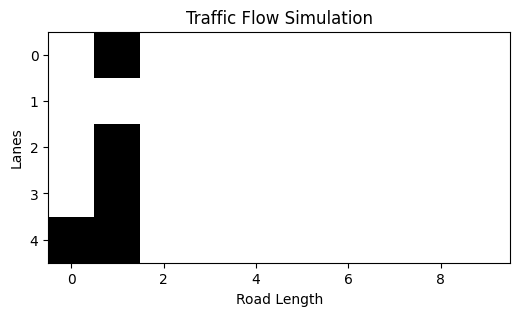

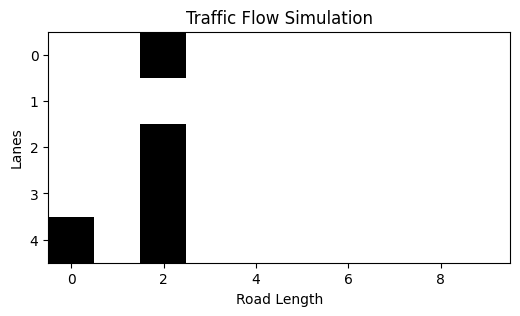

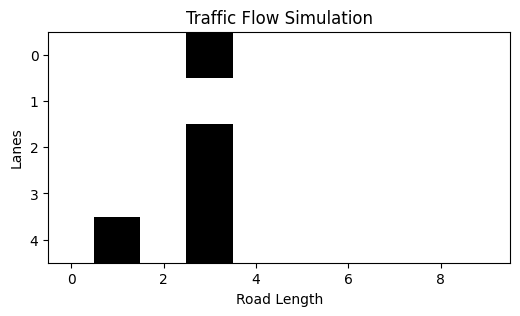

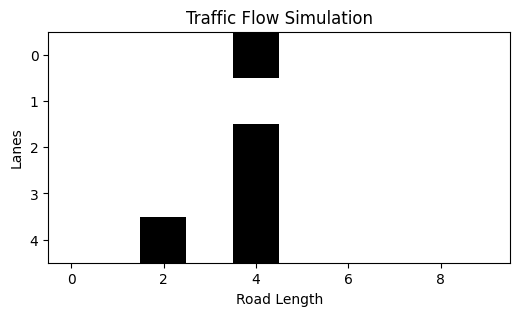

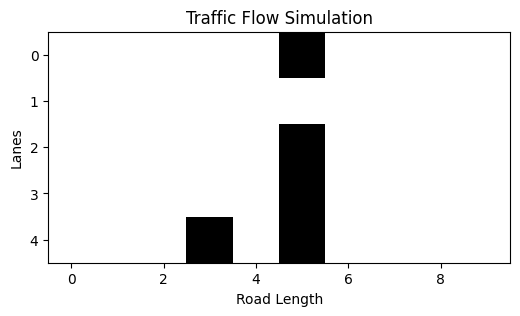

In [10]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import RandomActivation
import matplotlib.pyplot as plt
import numpy as np

class Car(Agent):
    """ A car that moves right if there is space ahead. """
    
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

    def step(self):
        """ Move the car forward if possible """
        x, y = self.pos  
        next_x = (x + 1) % self.model.grid.width  

        if self.model.grid.is_cell_empty((next_x, y)):  
            self.model.grid.move_agent(self, (next_x, y))  

class TrafficModel(Model):
    """ Traffic simulation model on a road grid. """
    
    def __init__(self, width, height, num_cars):
        self.grid = MultiGrid(width, height, torus=False)  
        self.schedule = RandomActivation(self)  

        # Add cars to the grid
        for i in range(num_cars):
            car = Car(i, self)
            self.schedule.add(car)
            
            
            x, y = 0, self.random.randint(0, height - 1)
            self.grid.place_agent(car, (x, y))

    def step(self):
        """Advance the simulation by one step."""
        self.schedule.step()

def plot_grid(model):
    """ Visualize the traffic grid. """
    grid_array = np.zeros((model.grid.height, model.grid.width))
    
    for agent in model.schedule.agents:
        x, y = agent.pos
        grid_array[y, x] = 1  
    
    plt.figure(figsize=(6, 3))
    plt.imshow(grid_array, cmap="gray_r", origin="upper")
    plt.title("Traffic Flow Simulation")
    plt.xlabel("Road Length")
    plt.ylabel("Lanes")
    plt.show()

# Run the simulation and visualize
traffic = TrafficModel(10, 5, 5)  

for i in range(5): 
    traffic.step()
    plot_grid(traffic)